This notebook showcases the fundamentals of data science through exploratory data analysis, data preprocessing, and basic machine learning techniques for customer churn prediction.

---


# Customer Churn Prediction

The objective of this project is to predict customer churn using machine learning techniques. The workflow includes:

* Data exploration and visualization
(EDA)
* Data cleaning and preprocessing
* Feature encoding and scaling
* Model training and evaluation
* Performance comparison between
* Logistic Regression and Random Forest

By the end of the project, we identify the model that provides the best predictive performance for customer churn.

---

## Why Churn?

Customer/client churn is one of the major challenges for companies, as losing customers directly impacts revenue and therefore the growth of any organization. The goal in this project is to identify customers and patterns that are likely to churn so the company can take proactive retention actions.

# Install and import libraries

In [50]:
#The code below is to install scikit-learn and be able to import it.
!pip install scikit-learn --quiet

#Now import the libraries that I'm going to use for the model that I'll train.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Load the data

The dataset used in this project was obtained from: https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv

In [51]:
# We define "url" to call the data.
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

# Now we define the DataFrame using the "url"
df = pd.read_csv(url)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 7043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Exploratory Data Analysis (EDA)

It is important to ensure that each column has the correct data type assigned. We can see that **TotalCharges** represents monetary values, so it should be stored as a **float64**, just like the **MonthlyCharges** column.


Let's investigate the issue with the **TotalCharges** column.

In [53]:
print(df['TotalCharges'].unique()[:10])
print("\nEmpty valus or spaces:")
print((df['TotalCharges'] == ' ').sum())

['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95']

Empty valus or spaces:
11


Now, let's analyze our target variable **Churn**.

In [54]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True).round(3) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


As shown below, more than a quarter of the customers in this dataset have already churned.

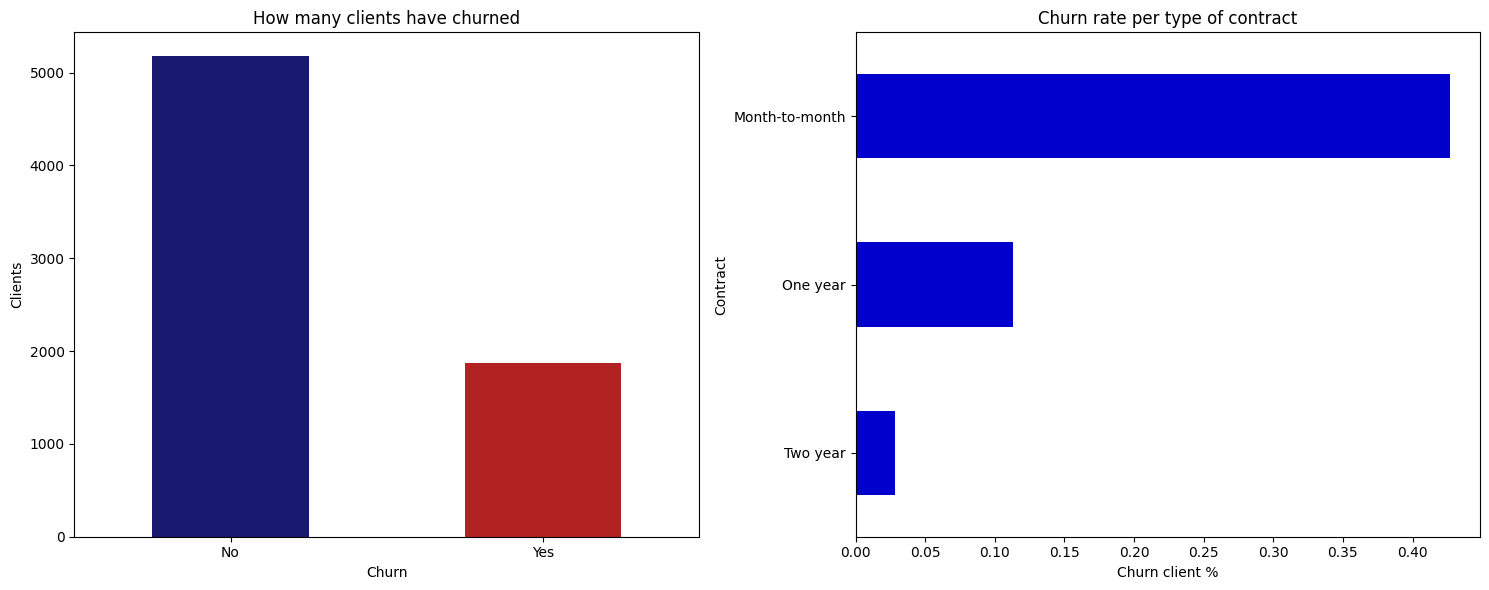

Saved as churn_analisys.png


In [55]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# First plot: How many clients have churned
df['Churn'].value_counts().plot(kind='bar', ax=axes[0],
    color=['midnightblue', 'firebrick'], edgecolor='none')
axes[0].set_title('How many clients have churned')
axes[0].set_ylabel('Clients')
axes[0].tick_params(rotation=0)

# Second plot: Churn rate per type of contract
df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()['Yes'].sort_values().plot(
    kind='barh', ax=axes[1], color='mediumblue', edgecolor='none')
axes[1].set_title('Churn rate per type of contract')
axes[1].set_xlabel('Churn client %')

plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as churn_analisys.png")

Based on the data above, we can see that customers with monthly contracts are more likely to churn eventually.

# Clean and prepare the data

In the following section, we fix the data type issue in the **TotalCharges** column and prepare the dataset for modeling.

In [56]:
#Here I replace the empty spaces with NaN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.info()

#Now I filled out the 11 NaN with the median.
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

#And we verify the results.
print(f"Type of data now: {df['TotalCharges'].dtype}")
print(f"Null values: {df['TotalCharges'].isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [57]:
#Now I drop the ID column since it doesn't contribute anything to the model.
df.drop(columns=['customerID'], inplace=True)

print(f"Columns left: {df.shape[1]}")

Columns left: 20


In [58]:
#Convert 'Churn' column from 'Yes'  or 'No' to '1' or '2'.
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [59]:
#Bellow we define which collumns we're going to put into the 'cat_cols' for its convertion.
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Columns to convert: {cat_cols}")

#Aply LabelEncoder to each column defined above.
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

#Now we verify there are no more object columns.
print(f"\nTypes of data values now:")
print(df.dtypes.value_counts())

Columns to convert: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Types of data values now:
int64      18
float64     2
Name: count, dtype: int64


In [60]:
# Here we separate X = everything and y = just Churn.
X = df.drop(columns=['Churn'])
y = df['Churn']

#Below we scalate every variable to have everyhing in the same scale.
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.head()

#This section is import: We split the train data and the test data.
#Train data = 80% and Test data = 20%.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train data: {X_train.shape[0]}")
print(f"Test data: {X_test.shape[0]}")


Train data: 5634
Test data: 1409


# Now let's train the models!

In this step, we train two machine learning models—Logistic Regression and Random Forest—and compare their performance to determine which one achieves better results.

# Logistic Regression

In [61]:
#Here I set the model and set the data that I'm going to use for training.
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

#Predictions
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Trained!")
print(f"AUC Score: {roc_auc_score(y_test, y_proba_lr):.3f}")

Logistic Regression Trained!
AUC Score: 0.840


# Random Forest


In [62]:
# Below I set the model that I will use and its data for training.
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

#Predictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Trained!")
print(f"AUC Score: {roc_auc_score(y_test, y_proba_rf):.3f}")

Random Forest Trained!
AUC Score: 0.825


Finally, we compare the performance of both models using key evaluation metrics.




In [63]:
print("=" * 45)
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr,
      target_names=['No Churn', 'Churn']))

print("=" * 45)
print("Random Forest")
print("=" * 45)
print(classification_report(y_test, y_pred_rf,
      target_names=['No Churn', 'Churn']))


Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Random Forest
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



Based on the results above, both models perform well: **Logistic regression had an AUC score of 0.840** and **random forest had 0.825**; however, since churn prediction is a classification problem, multiple metrics were used to evaluate model performance, including accuracy, precision, recall, F1-score, and ROC-AUC. **Recall** is particularly important in this context because identifying potential churners is more valuable than simply maximizing overall accuracy.

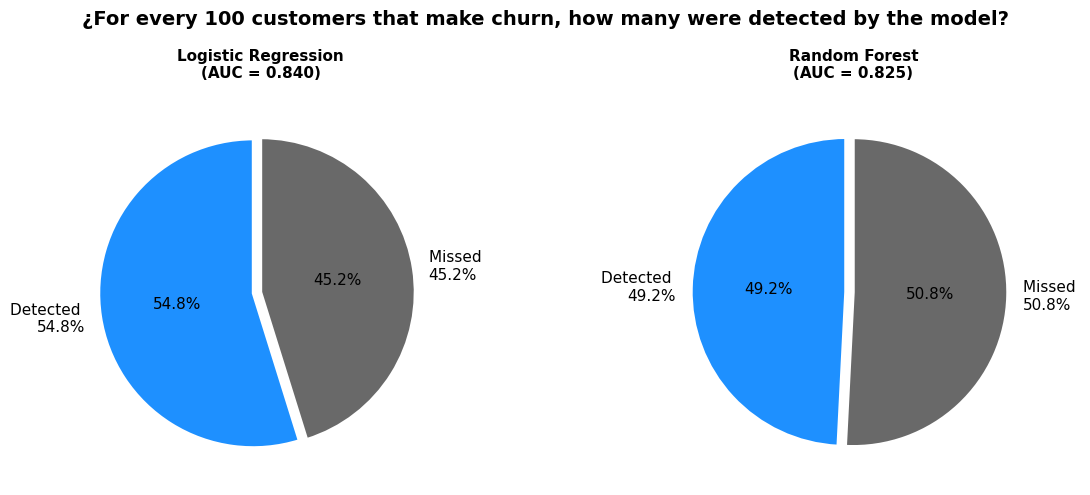

In [64]:
from sklearn.metrics import recall_score

#We calculate the recall per clase for each model
recall_lr = recall_score(y_test, y_pred_lr, pos_label=1)
recall_rf = recall_score(y_test, y_pred_rf, pos_label=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('¿For every 100 customers that make churn, how many were detected by the model?', fontsize=14, fontweight='bold')

#Define values, labels, colors for the pie charts
labels = ['No Churn', 'Churn']
colors = ['gray', 'blue']

for ax, (name, recall) in zip(axes, [
    ('Logistic Regression', recall_lr),
    ('Random Forest',       recall_rf)
]):
    detected  = recall
    missed    = 1 - recall
    values    = [detected, missed]
    labels    = [f'Detected \n{detected:.1%}', f'Missed \n{missed:.1%}']
    colors    = ['dodgerblue', 'dimgray']
    explode   = (0.05, 0)

    ax.pie(values, labels=labels, colors=colors,
           explode=explode, startangle=90,
           autopct= '%1.1f%%', pctdistance=0.50,
           wedgeprops=dict(edgecolor='white', linewidth=2),
           textprops=dict(fontsize=11))
    ax.set_title(f'{name}\n(AUC = {roc_auc_score(y_test, y_proba_lr if "Logistic" in name else y_proba_rf):.3f})',
                fontsize=11, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('recall_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Why Does Recall Matter Most in This Context?

In customer churn prediction, the primary objective is to identify customers who are likely to leave the company before they actually do.

A **false negative** occurs when the model predicts that a customer will stay, but the customer churns at the end. This is kind of costly because the company loses the opportunity to take actions like offering a discount, personalized support, or loyalty incentives.

Recall, on the other side, measures the percentage of actual churners that the model could actually identify: Recall=TP/+FNTP​.

A higher recall means fewer churning customers are missed, allowing the business to identify them and act and improve customer retention for those specific ones.

Even though both models were really closed based on their overall performance, The **Logistic Regression model identified 6.1% more** customers who eventually churned than Random Forest.

From a business perspective, failing to identify a customer who is about to leave is typically more costly than falsely flagging a customer as at risk when it is not **True**.

## Business Impact

Let's imagine that a SaaS company has 10,000 customers and around 25% of them are at risk of churning.

*   Logistic Regression would identify roughly 548 out of every 1,000 churners.
*   Random Forest would identify roughly 487 out of every 1,000 churners.

In this example **the difference** is 61, but for larger companies the scale and the results are more impactful, and it **could represent dozens or even hundreds of retained customers, resulting in significant revenue savings.**

Therefore, having this in mind, Logistic Regression may be preferred when customer retention is the primary objective.




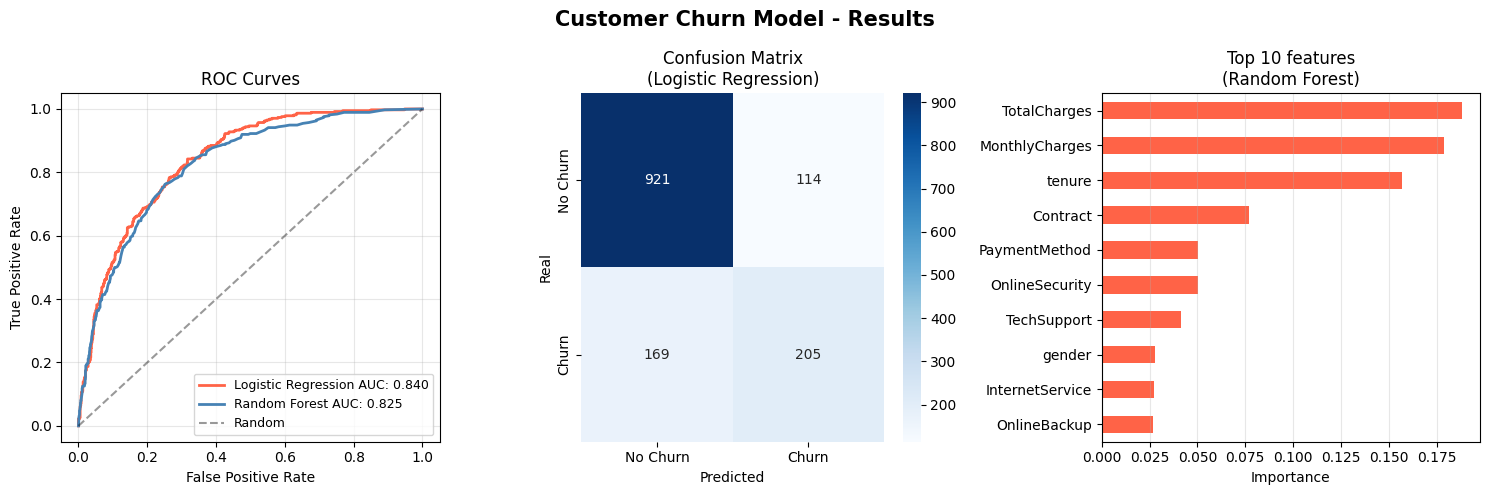

Saved as churn_results.png


In [65]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Customer Churn Model - Results', fontsize=15, fontweight='bold')

# ROC Curves
for name, proba, color in zip(
        ['Logistic Regression', 'Random Forest'],
        [y_proba_lr, y_proba_rf],
        ['tomato', 'steelblue']):
    fpr, tpr, _= roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} AUC: {auc:.3f}')

axes[0].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[1].set_title('Confusion Matrix\n(Logistic Regression)')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicted')

# Feature Importance (Random Forest)
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(
    kind='barh', ax=axes[2], color='tomato', edgecolor='none')
axes[2].set_title('Top 10 features\n(Random Forest)')
axes[2].set_xlabel('Importance')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('churn_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as churn_results.png")

## Conclusion

This project demonstrates a complete machine learning workflow for customer churn prediction, from data preprocessing to model evaluation. Among the models tested, Logistic Regression achieved the best predictive performance, indicating that non-linear relationships and feature interactions play an important role in customer churn behavior.

**Future improvements:**

*   Perform hyperparameter tunning using GridSearchCV.
*   Address class imbalance with techniques such as SMOTE.
*   Experiment with additional models like XGBoost or LightGBM.
*   Deploy the model as a web application or API for real-time predictions.



